In [1]:
import pandas as pd
import numpy as np

# Load the raw dataset cleanly from your local path
file_path = "/workspaces/Machine-Learning-Project/data/Subscription_Service_Churn_Dataset.csv"
df = pd.read_csv(file_path)

# Verify shape and contents
print(f"Dataset successfully loaded! Shape: {df.shape}")
df.head()

Dataset successfully loaded! Shape: (963, 21)


,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,42,11.321950,475.521914,Basic,Electronic check,Yes,Movies,Yes,Tablet,0.386852,...,25,Comedy,3.489465,7,Female,15,No,No,LOHRYYC9E8,0
1,95,12.810915,1217.036887,Standard,Electronic check,Yes,TV Shows,No,Mobile,37.123000,...,21,Comedy,2.251860,3,Male,8,No,NaN,RIH7RFEZCS,0
2,6,NaN,91.583304,Standard,Credit card,Yes,TV Shows,No,Tablet,30.716944,...,29,Fantasy,NaN,4,Male,14,No,Yes,JB5J8X2UY1,1
3,54,17.917819,967.562224,Basic,NaN,Yes,Movies,No,Mobile,2.495373,...,45,Drama,1.275004,3,Male,12,No,NaN,Z4GZJIB90P,0
4,27,NaN,339.057244,Basic,Mailed check,No,TV Shows,No,Mobile,39.936910,...,44,Comedy,3.236230,4,Female,18,No,NaN,B3BDJTW0L9,0


In [2]:
#Checking each column's data type in the dataset.
columns = df.columns
print("Data type of each column:")
print(df.dtypes)

Data type of each column:
AccountAge                    int64
MonthlyCharges              float64
TotalCharges                float64
SubscriptionType                str
PaymentMethod                   str
PaperlessBilling                str
ContentType                     str
MultiDeviceAccess               str
DeviceRegistered                str
ViewingHoursPerWeek         float64
AverageViewingDuration      float64
ContentDownloadsPerMonth      int64
GenrePreference                 str
UserRating                  float64
SupportTicketsPerMonth        int64
Gender                          str
WatchlistSize                 int64
ParentalControl                 str
SubtitlesEnabled                str
CustomerID                      str
Churn                         int64
dtype: object


In [3]:
#Checking for missing values in the dataset
missing_columns = (df.columns[df.isnull().any()])
missing_col_no = len(missing_columns)
print("Number of columns with missing values:", missing_col_no)
#Data type of columns with missing values
print("Data type of missing values:")
print(df[missing_columns].dtypes)

Number of columns with missing values: 9
Data type of missing values:
MonthlyCharges      float64
TotalCharges        float64
SubscriptionType        str
PaymentMethod           str
DeviceRegistered        str
GenrePreference         str
UserRating          float64
Gender                  str
SubtitlesEnabled        str
dtype: object


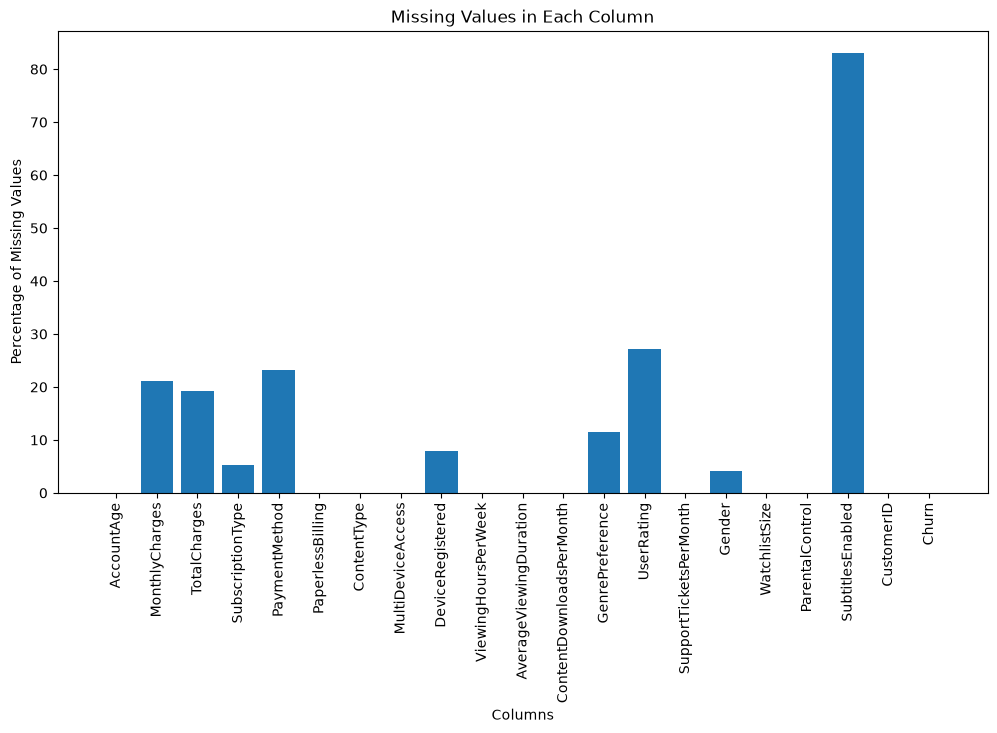

In [4]:
import matplotlib.pyplot as plt
#Visualizing the missing values in the dataset using a barchart.
missing_values = df.isnull().mean() * 100
plt.figure(figsize=(12, 6))
plt.bar(missing_values.index, missing_values)
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.title('Missing Values in Each Column')  
plt.show()

In [5]:
#Checking for duplicate rows in the dataset
import pandas as pd
df = pd.read_csv ("/workspaces/Machine-Learning-Project/data/Subscription_Service_Churn_Dataset.csv")
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows in the dataset:", duplicate_rows)

Number of duplicate rows in the dataset: 0


In [6]:
#Checking for class imbalance in the target variable
target_column = 'Churn'

# Check raw counts
print("Class Distribution (Counts):")
print(df[target_column].value_counts())

print("\n" + "=" * 40 + "\n")

# Check percentages to see the exact imbalance ratio
print("Class Distribution (Percentages):")
print(df[target_column].value_counts(normalize=True) * 100)

Class Distribution (Counts):
Churn
0    794
1    169
Name: count, dtype: int64


Class Distribution (Percentages):
Churn
0    82.450675
1    17.549325
Name: proportion, dtype: float64


In [7]:
import pandas as pd

# Identifying categorical and numerical columns in the dataset
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Combining them into a dictionary
data_structure = {
    'Categorical Columns': pd.Series(categorical_columns),
    'Numerical Columns': pd.Series(numerical_columns)
}

# Create a summary DataFrame
summary_table = pd.DataFrame(data_structure)

# Fill empty spots with a blank string for a cleaner look
summary_table = summary_table.fillna('')
summary_table


/tmp/ipykernel_27685/1278856168.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


,Categorical Columns,Numerical Columns
0,SubscriptionType,AccountAge
1,PaymentMethod,MonthlyCharges
2,PaperlessBilling,TotalCharges
3,ContentType,ViewingHoursPerWeek
4,MultiDeviceAccess,AverageViewingDuration
5,DeviceRegistered,ContentDownloadsPerMonth
6,GenrePreference,UserRating
7,Gender,SupportTicketsPerMonth
8,ParentalControl,WatchlistSize
9,SubtitlesEnabled,Churn


In [8]:
#Checking for outliers in the numerical columns using IQR method
import pandas as pd
outlier_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Identify which columns actually contain outliers
columns_with_outliers = []

for col in outlier_columns:
    if df[col].nunique() <= 2:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Check if any value falls outside the bounds
    has_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).any()
    
    if has_outliers:
        columns_with_outliers.append(col)


if len(columns_with_outliers) > 0:
    print(f"The columns are: {columns_with_outliers}")
else:
    print("No columns with outliers found.")

The columns are: ['TotalCharges']


In [10]:
# Calculating IQR bounds for TotalCharges specifically
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter rows that fall outside the bounds
outliers = df[(df['TotalCharges'] < lower_bound) | (df['TotalCharges'] > upper_bound)]

print(f"Number of outlier rows in TotalCharges: {len(outliers)}")
print(f"Total dataset rows: {len(df)}")

Number of outlier rows in TotalCharges: 10
Total dataset rows: 963


In [ ]:
#Filling missing values in the dataset based on the data type of each column
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object' or df[col].dtype == 'str':
            # Fill categorical/string columns with the mode
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            # Fill numerical columns with the mean
            df[col] = df[col].fillna(df[col].mean())

In [12]:
#Checking for missing values after filling them
missing_values = df.isnull().sum()
print("Number of columns after filling missing values:", missing_values[missing_values > 0].shape[0])

Number of columns after filling missing values: 0


In [13]:
#Isolating the target variable from the features.
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

In [ ]:
# Filtering the columns that have text/object data types
categorical_cols = df.select_dtypes(include=["string", "object"]).columns

#Initializing category types for categorical columns
binary_counts = 0
multiclass_counts = 0

# Print the number of unique values for each categorical column
for col in categorical_cols:
  unique_values_count = df[col].nunique()
  print(f"{col}: {unique_values_count} unique values")

#Categorizing based on unique values count
  if unique_values_count == 2:
    binary_counts += 1
  elif unique_values_count > 2:
    multiclass_counts += 1

print(f"Total binary columns: {binary_counts}")
print(f"Total multi-class columns: {multiclass_counts}")

SubscriptionType: 3 unique values
PaymentMethod: 4 unique values
PaperlessBilling: 2 unique values
ContentType: 3 unique values
MultiDeviceAccess: 2 unique values
DeviceRegistered: 4 unique values
GenrePreference: 5 unique values
Gender: 2 unique values
ParentalControl: 2 unique values
SubtitlesEnabled: 2 unique values
CustomerID: 963 unique values
Total binary columns: 5
Total multi-class columns: 6


In [15]:
from sklearn.preprocessing import LabelEncoder

# Initializing counters
binary_counts = 0
multiclass_counts = 0

le = LabelEncoder()

# Loop through your categorical columns
for col in categorical_cols:
  # Skipping CustomerID since it's an identifier, not a feature
  if col == "CustomerID":
    continue

  unique_values_count = df[col].nunique()

  if unique_values_count == 2:
    binary_counts += 1
    df[col] = le.fit_transform(df[col])

  elif unique_values_count > 2:
    multiclass_counts += 1
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(columns=[col])  # Drop the original text column

In [16]:
#Checking the final structure of the DataFrame after encoding as per the unique values.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   AccountAge                      963 non-null    int64  
 1   MonthlyCharges                  963 non-null    float64
 2   TotalCharges                    963 non-null    float64
 3   PaperlessBilling                963 non-null    int64  
 4   MultiDeviceAccess               963 non-null    int64  
 5   ViewingHoursPerWeek             963 non-null    float64
 6   AverageViewingDuration          963 non-null    float64
 7   ContentDownloadsPerMonth        963 non-null    int64  
 8   UserRating                      963 non-null    float64
 9   SupportTicketsPerMonth          963 non-null    int64  
 10  Gender                          963 non-null    int64  
 11  WatchlistSize                   963 non-null    int64  
 12  ParentalControl                 963 non-null   

In [17]:
# List of binary columns to exclude from scaling
binary_columns = [
    "PaperlessBilling",
    "MultiDeviceAccess",
    "Gender",
    "ParentalControl",
    "SubtitlesEnabled",
]

# Select numeric columns, excluding binary columns, Churn, and CustomerID
cols_to_scale = (
    df.select_dtypes(include=["int64", "float64"])
    .drop(columns=binary_columns, errors="ignore")
    .columns.tolist()
)

if "Churn" in cols_to_scale:
  cols_to_scale.remove("Churn")

print("Columns that actually need feature scaling:")
for col in cols_to_scale:
  print(f"- {col} (Min: {df[col].min():.2f}, Max: {df[col].max():.2f})")

Columns that actually need feature scaling:
- AccountAge (Min: 1.00, Max: 119.00)
- MonthlyCharges (Min: 5.06, Max: 19.93)
- TotalCharges (Min: 11.58, Max: 2261.02)
- ViewingHoursPerWeek (Min: 0.32, Max: 39.95)
- AverageViewingDuration (Min: 5.03, Max: 179.75)
- ContentDownloadsPerMonth (Min: 0.00, Max: 49.00)
- UserRating (Min: 1.00, Max: 5.00)
- SupportTicketsPerMonth (Min: 0.00, Max: 9.00)
- WatchlistSize (Min: 0.00, Max: 24.00)


In [ ]:
# 1. Finding any columns that still contain text/strings
text_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Found unencoded text columns: {text_cols}")

# 2. Force convert all text columns into numeric dummy variables
X = pd.get_dummies(X, columns=text_cols, drop_first=True)

print(f"New feature shape after encoding all text columns: {X.shape}")

Found unencoded text columns: ['SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled']
New feature shape after encoding all text columns: (963, 28)


/tmp/ipykernel_27685/641417506.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Spliting into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# 2. Scaling continuous columns (fit ONLY on X_train to prevent data leakage)
continuous_cols = [
    "AccountAge", "MonthlyCharges", "TotalCharges", 
    "ViewingHoursPerWeek", "AverageViewingDuration", 
    "ContentDownloadsPerMonth", "UserRating", 
    "SupportTicketsPerMonth", "WatchlistSize"
]
valid_continuous_cols = [col for col in continuous_cols if col in X_train.columns]

scaler = StandardScaler()
X_train[valid_continuous_cols] = scaler.fit_transform(X_train[valid_continuous_cols])
X_test[valid_continuous_cols] = scaler.transform(X_test[valid_continuous_cols])

# 3. Applying SMOTE strictly to the training set to fix class imbalance
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 4. Formating arrays and shapes for your custom NumPy model
y_train_balanced = y_train_balanced.to_numpy().reshape(-1, 1)
X_train_balanced = X_train_balanced.to_numpy()
X_test_array = X_test.to_numpy()

print(f"Final Balanced X_train shape: {X_train_balanced.shape}")
print(f"Final Balanced y_train shape: {y_train_balanced.shape}")

Training set shape: (770, 28)
Testing set shape: (193, 28)
Final Balanced X_train shape: (1270, 28)
Final Balanced y_train shape: (1270, 1)


In [ ]:
# Checking the first few rows of a continuous column to see if it's scaled
print(df[["MonthlyCharges", "TotalCharges"]].head())

   MonthlyCharges  TotalCharges
0       11.321950    475.521914
1       12.810915   1217.036887
2       12.328262     91.583304
3       17.917819    967.562224
4       12.328262    339.057244


In [28]:
import numpy as np

def initialize_parameters(dim):
    """
    Initializes the model's weights to zeros and the bias to zero.
        
    Argument:
    dim -- the number of features in the training data
        
    Returns:
    w -- initialized weight vector of shape (dim, 1)
    b -- initialized scalar bias (0.0)
    """
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

# Determine the number of features from X_train_balanced and initialize parameters
n_features = X_train_balanced.shape[1]
w, b = initialize_parameters(n_features)

print("Parameters initialized successfully!")
print(f"Weights shape: {w.shape}")
print(f"Bias value: {b}")

Parameters initialized successfully!
Weights shape: (28, 1)
Bias value: 0.0


In [29]:
# Sigmoid function to map any real value into the range [0, 1]
def sigmoid(z):
    """
    Compute the sigmoid of z
    Arguments:
    z -- A scalar or numpy array of any size.
    Return:
    s -- sigmoid(z)
    """
    s = 1 / (1 + np.exp(-z))
    return s

In [30]:
#Binary cross-entropy cost function to evaluate the performance of the model
def compute_cost(A, Y):
    """
    Computes the binary cross-entropy cost.
    
    Arguments:
    A -- sigmoid output of shape (1, number of examples) or matching Y
    Y -- true "label" vector of shape (1, number of examples) or matching Y
    
    Returns:
    cost -- cross-entropy cost
    """
    m = Y.shape[0] if isinstance(Y, np.ndarray) else len(Y)
    
    # Adding a tiny epsilon to prevent log(0) errors
    epsilon = 1e-15
    A = np.clip(A, epsilon, 1 - epsilon)
    
    # Computing cost
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    
    # Ensuring cost is a scalar
    cost = np.squeeze(cost)
    
    return cost

In [31]:
# Forward and backward propagation to compute gradients and cost
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for forward and backward propagation
    """
    m = X.shape[0]  # Number of training examples
    
    # Forward propagation: X is (m, 28), w is (28, 1) -> Z is (m, 1)
    Z = np.dot(X, w) + b
    A = 1 / (1 + np.exp(-Z))
    
    # Ensure Y is properly shaped as (m, 1)
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)
        
    # Compute cost with numerical stability offset
    cost = (-1 / m) * np.sum(Y * np.log(A + 1e-15) + (1 - Y) * np.log(1 - A + 1e-15))
    
    # Backward propagation (gradients)
    # X.T is (28, m), (A - Y) is (m, 1) -> dw is (28, 1)
    dw = (1 / m) * np.dot(X.T, (A - Y))
    db = (1 / m) * np.sum(A - Y)
    
    cost = np.squeeze(cost)
    grads = {"dw": dw, "db": db}
    
    return grads, cost

In [ ]:
#Checking whether the data types of X_train and y_train are compatible with NumPy operations
print("--- X_train Check ---")
print(f"Type: {type(X_train)}")
print(f"Data type (dtype): {getattr(X_train, 'dtype', 'Not an array/no dtype')}")

print("\n--- y_train Check ---")
print(f"Type: {type(y_train)}")
print(f"Data type (dtype): {getattr(y_train, 'dtype', 'Not an array/no dtype')}")

--- X_train Check ---
Type: <class 'pandas.DataFrame'>
Data type (dtype): Not an array/no dtype

--- y_train Check ---
Type: <class 'pandas.Series'>
Data type (dtype): int64


In [39]:
# Force-convert the data into clean numeric float arrays for NumPy
X_train = np.array(X_train, dtype=float)
y_train = np.array(y_train, dtype=float)

print(f"X_train type after conversion: {type(X_train)}, shape: {X_train.shape}")
print(f"y_train type after conversion: {type(y_train)}, shape: {y_train.shape}")
print("=" * 100 + "\n")
#Checking again
print("--- X_train Check ---")
print(f"Type: {type(X_train)}")
print(f"Data type (dtype): {getattr(X_train, 'dtype', 'Not an array/no dtype')}")

print("\n--- y_train Check ---")
print(f"Type: {type(y_train)}")
print(f"Data type (dtype): {getattr(y_train, 'dtype', 'Not an array/no dtype')}")

X_train type after conversion: <class 'numpy.ndarray'>, shape: (770, 28)
y_train type after conversion: <class 'numpy.ndarray'>, shape: (770,)

--- X_train Check ---
Type: <class 'numpy.ndarray'>
Data type (dtype): float64

--- y_train Check ---
Type: <class 'numpy.ndarray'>
Data type (dtype): float64


In [41]:
# Matching the 'w' to the number of features the dataset has
dim = X_train.shape[1]  # 28 features
w = np.zeros((dim, 1))  # Shape becomes (28, 1)
b = 0.0

# Running a single forward/backward propagation pass test
grads, cost = propagate(w, b, X_train, y_train)

print("Propagation test executed successfully!")
print(f"Initial Cost: {cost:.4f}")
print(f"dw shape: {grads['dw'].shape}")
print(f"db value: {grads['db']:.4f}")

Propagation test executed successfully!
Initial Cost: 0.6931
dw shape: (28, 1)
db value: 0.3247


In [43]:
import numpy as np

def optimize(w, b, X, Y, num_iterations, learning_rate):
    """
    Optimizes w and b by running a gradient descent algorithm
    Arguments:
    w -- weights, a numpy array of size (number of features, 1)
    b -- bias, a scalar
    X -- data of shape (number of examples, number of features)
    Y -- true "label" vector of shape (number of examples, 1)
    num_iterations -- number of iterations for optimization
    learning_rate -- learning rate for gradient descent
    Returns:
    params -- dictionary containing the weights and bias
    grads -- dictionary containing the gradients of the weights and bias
    costs -- list of costs during optimization
    """
    
    # Defensive Safeguards: Ensure clean NumPy arrays and correct dimensions
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)

    costs = []

    for i in range(num_iterations):
        # Computing gradients and cost
        grads, cost = propagate(w, b, X, Y)

        # Retrieving derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # Updating parameters using gradient descent
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Recording the cost every 100 iterations
        if i % 100 == 0:
            costs.append(cost)
            print(f"Cost after iteration {i}: {cost:.4f}")

    # Packing the optimized weights and bias into params
    params = {
        "w": w,
        "b": b
    }
    
    return params, grads, costs

In [45]:
params, grads, costs = optimize(w, b, X_train_balanced, y_train_balanced, num_iterations=2000, learning_rate=0.01)

print("\nOptimization completed successfully!")
print(f"Final optimized bias (b): {params['b']}")
print(f"Final optimised cost: {costs[-1]:.4f}")

Cost after iteration 0: 0.6931
Cost after iteration 100: 0.6375
Cost after iteration 200: 0.6073
Cost after iteration 300: 0.5876
Cost after iteration 400: 0.5737
Cost after iteration 500: 0.5633
Cost after iteration 600: 0.5553
Cost after iteration 700: 0.5489
Cost after iteration 800: 0.5435
Cost after iteration 900: 0.5390
Cost after iteration 1000: 0.5350
Cost after iteration 1100: 0.5315
Cost after iteration 1200: 0.5284
Cost after iteration 1300: 0.5255
Cost after iteration 1400: 0.5228
Cost after iteration 1500: 0.5204
Cost after iteration 1600: 0.5181
Cost after iteration 1700: 0.5159
Cost after iteration 1800: 0.5138
Cost after iteration 1900: 0.5119

Optimization completed successfully!
Final optimized bias (b): -0.6619373851938759
Final optimised cost: 0.5119


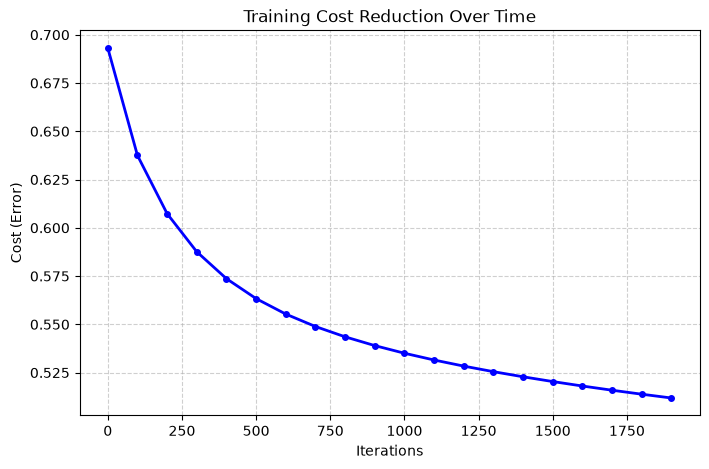

In [46]:
import matplotlib.pyplot as plt

# Generating the actual iteration milestones (0, 100, 200, ..., 1900)
iterations = range(0, len(costs) * 100, 100)

plt.figure(figsize=(8, 5))
plt.plot(iterations, costs, color='blue', linewidth=2, marker='o', markersize=4)
plt.ylabel('Cost (Error)')
plt.xlabel('Iterations')
plt.title('Training Cost Reduction Over Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [47]:
import numpy as np
import pandas as pd
#Extracting the updated w and b into global variables
w = params["w"]
b = params["b"]
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)
np.save('w.npy', w)
np.save('b.npy', b)

print("Trained weights and test data saved successfully!")
print("Checking w shape:", w.shape)
print("Checking b value:", b)
print("Updated w sum:", np.sum(np.abs(w)))
print("Updated b:", b)

Trained weights and test data saved successfully!
Checking w shape: (28, 1)
Checking b value: -0.6619373851938759
Updated w sum: 5.798825906824015
Updated b: -0.6619373851938759


In [48]:
import numpy as np

unique_classes, counts = np.unique(y_test, return_counts=True)
class_distribution = dict(zip(unique_classes, counts))
print("Test set class distribution:", class_distribution)

# Calculating baseline accuracy of a dummy model that always predicts the majority class
majority_class_count = np.max(counts)
baseline_accuracy = (majority_class_count / len(y_test)) * 100
print(f"Naive Baseline Accuracy: {baseline_accuracy:.2f}%")

Test set class distribution: {np.int64(0): np.int64(159), np.int64(1): np.int64(34)}
Naive Baseline Accuracy: 82.38%


In [3]:
import numpy as np
print("Current type of np:", type(np))

Current type of np: <class 'module'>


In [4]:
import numpy as np
from sklearn.metrics import accuracy_score

# Define the predict function with explicit float casting
def predict(w, b, X):
    # Ensure inputs are strictly numeric float64 arrays
    X = X.astype(np.float64)
    w = w.astype(np.float64).reshape(X.shape[1], 1)
    b = float(b) if np.ndim(b) == 0 else b.astype(np.float64)
    
    m = X.shape[0]
    Y_prediction = np.zeros((m, 1))
    
    # Compute activation probabilities safely
    A = 1 / (1 + np.exp(-(np.dot(X, w) + b)))
    
    for i in range(A.shape[0]):
        if A[i] > 0.5:
            Y_prediction[i] = 1
        else:
            Y_prediction[i] = 0
            
    return Y_prediction

# Load weights and test set with pickle enabled
w = np.load('w.npy', allow_pickle=True)
b = np.load('b.npy', allow_pickle=True)
X_test = np.load('X_test.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

# Generate predictions using your custom predict function
y_pred = predict(w, b, X_test)

# Flatten to ensure 1D arrays and calculate accuracy
y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

accuracy = accuracy_score(y_test_flat, y_pred_flat) * 100
print(f"Model Test Accuracy: {accuracy:.2f}%")

Model Test Accuracy: 67.88%
